In [1]:
%load_ext autoreload
%autoreload 2

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd


dataset = load_dataset("pubmed_qa", "pqa_labeled")

def build_context(example):
    example["combined_context"] = " ".join(example["context"]["contexts"])
    return example

dataset = dataset.map(build_context)

df = dataset["train"].to_pandas()

# Our 3 fields
df = df[["question", "combined_context", "final_decision"]]

# renaming vars
df = df.rename(columns={
    "combined_context": "context",
    "final_decision": "label"
})

df.head()

C:\Users\Alex\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,question,context,label
0,Do mitochondria play a role in remodelling lac...,Programmed cell death (PCD) is the regulated d...,yes
1,Landolt C and snellen e acuity: differences in...,Assessment of visual acuity depends on the opt...,no
2,"Syncope during bathing in infants, a pediatric...",Apparent life-threatening events in infants ar...,yes
3,Are the long-term results of the transanal pul...,The transanal endorectal pull-through (TERPT) ...,no
4,Can tailored interventions increase mammograph...,Telephone counseling and tailored print commun...,yes


Instructions to load the dataset from the given worksheet

In [2]:
import json

with open("predictions_biowordvec_svm.json", "r") as f:
    pred_dict = json.load(f)


In [3]:
print(type(pred_dict))
print(list(pred_dict.items())[:5])

<class 'dict'>
[('12377809', 'yes'), ('26163474', 'yes'), ('19100463', 'yes'), ('18537964', 'no'), ('12913878', 'yes')]


In [4]:
df_pred = pd.DataFrame(list(pred_dict.items()), columns=["pubid", "predicted_label"])
df_pred.head()

,pubid,predicted_label
0,12377809,yes
1,26163474,yes
2,19100463,yes
3,18537964,no
4,12913878,yes


In [5]:
from datasets import load_dataset

dataset = load_dataset("pubmed_qa", "pqa_labeled")

df_true = dataset["train"].to_pandas()

df_true = df_true[["pubid", "final_decision"]]
df_true = df_true.rename(columns={"final_decision": "true_label"})

df_true.head()

,pubid,true_label
0,21645374,yes
1,16418930,no
2,9488747,yes
3,17208539,no
4,10808977,yes


In [6]:
df_pred["pubid"] = df_pred["pubid"].astype(str)
df_true["pubid"] = df_true["pubid"].astype(str)

df = df_pred.merge(df_true, on="pubid")
df.head()

,pubid,predicted_label,true_label
0,12377809,yes,yes
1,26163474,yes,yes
2,19100463,yes,yes
3,18537964,no,yes
4,12913878,yes,yes


In [7]:
df["correct"] = (df["predicted_label"] == df["true_label"]).astype(int)

df.head()

,pubid,predicted_label,true_label,correct
0,12377809,yes,yes,1
1,26163474,yes,yes,1
2,19100463,yes,yes,1
3,18537964,no,yes,0
4,12913878,yes,yes,1


In [8]:
df_questions = dataset["train"].to_pandas()[["pubid", "question"]]

df_questions["pubid"] = df_questions["pubid"].astype(str)

df = df.merge(df_questions, on="pubid")
df.head()

,pubid,predicted_label,true_label,correct,question
0,12377809,yes,yes,1,Is anorectal endosonography valuable in dysche...
1,26163474,yes,yes,1,Is there a connection between sublingual varic...
2,19100463,yes,yes,1,Is the affinity column-mediated immunoassay me...
3,18537964,no,yes,0,Does a physician's specialty influence the rec...
4,12913878,yes,yes,1,Locoregional opening of the rodent blood-brain...


In [9]:
df["q_len"] = df["question"].apply(lambda x: len(x.split()))
df["has_number"] = df["question"].str.contains(r"\d", regex=True)
df["q_start"] = df["question"].apply(lambda x: x.split()[0].lower())

In [10]:
df["correct"].mean()

0.45

Overall accuracy is 0.45, which is weak

In [11]:
df.groupby("true_label")["correct"].mean()

true_label
maybe    0.290909
no       0.431953
yes      0.492754
Name: correct, dtype: float64

Classwise performace, maybe is the hardest with the lowest accuracy, meaning the model struggles with ambiguity.
yes is easiest, meaning there is likely a dataset bias or easier patterns.

In [12]:
df["correct"].value_counts(normalize=True)

correct
0    0.55
1    0.45
Name: proportion, dtype: float64

How many predictions are correct? It is fairly balanced indicating a stable model.

In [13]:
df.groupby("has_number")["correct"].mean()

has_number
False    0.465066
True     0.285714
Name: correct, dtype: float64

Do numbers add diffculty? False > True, so numbers do add difficulty

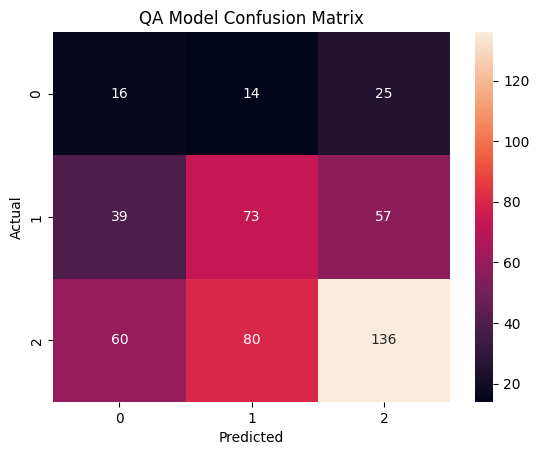

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(df["true_label"], df["predicted_label"])

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("QA Model Confusion Matrix")
plt.show()

0 represents yes
1 represents no
2 represents maybe

There is a lot of confusion for the maybe class

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[["q_len", "has_number"]]
y = df["correct"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.55
              precision    recall  f1-score   support

           0       0.54      0.92      0.69        53
           1       0.60      0.13      0.21        47

    accuracy                           0.55       100
   macro avg       0.57      0.53      0.45       100
weighted avg       0.57      0.55      0.46       100



The accuracy is a bit above 0.5, indicating that question features slightly help predict the difficultly

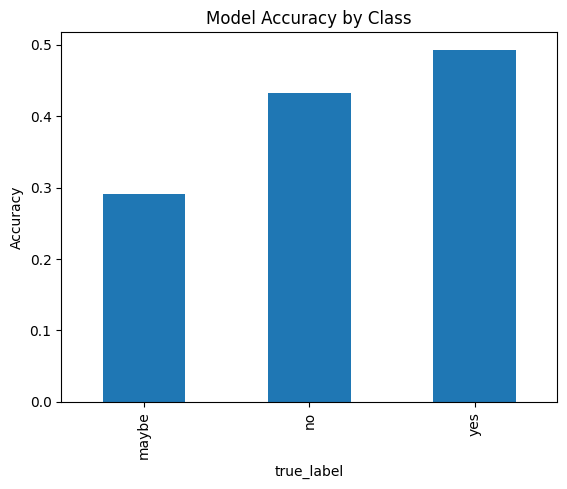

In [17]:
(df.groupby("true_label")["correct"].mean()).plot(kind="bar")
plt.title("Model Accuracy by Class")
plt.ylabel("Accuracy")
plt.show()

Maybe performs the worst. This suggests there is an ambiguity problem.

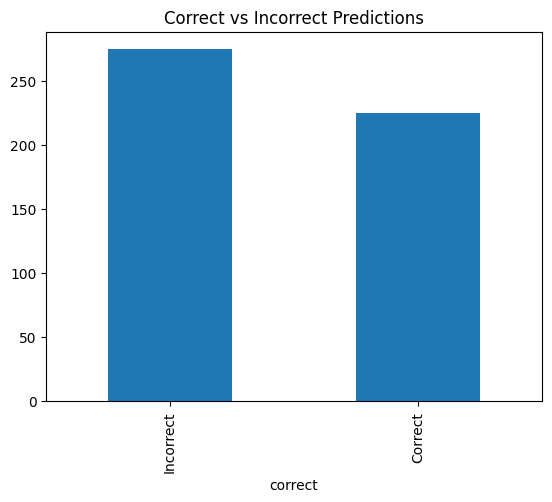

In [18]:
df["correct"].value_counts().plot(kind="bar")
plt.title("Correct vs Incorrect Predictions")
plt.xticks([0,1], ["Incorrect", "Correct"])
plt.show()

Overall, the model is not that strong given more than half of the predictions are incorrect.

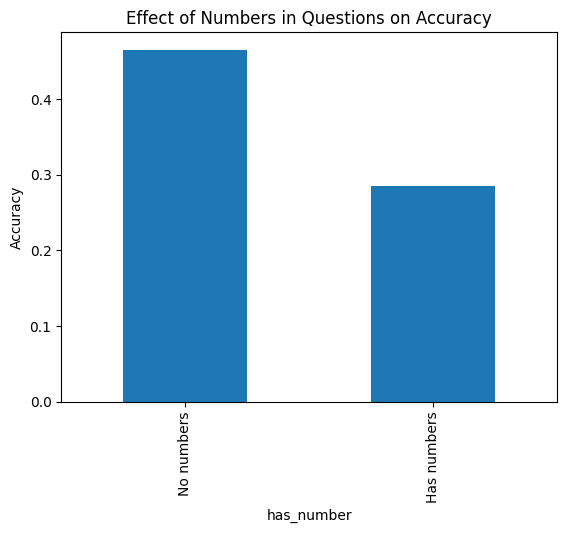

In [20]:
df.groupby("has_number")["correct"].mean().plot(kind="bar")
plt.title("Effect of Numbers in Questions on Accuracy")
plt.xticks([0,1], ["No numbers", "Has numbers"])
plt.ylabel("Accuracy")
plt.show()

The model struggles with questions that contain numbers, with a significantly lower accuracy score for those questions which do, suggesting the model struggles with numerical reasoning.

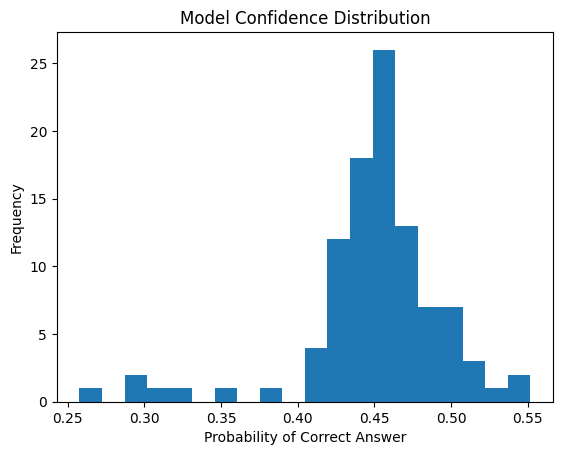

In [22]:
probs = model.predict_proba(X_test)[:,1]

plt.hist(probs, bins=20)
plt.title("Model Confidence Distribution")
plt.xlabel("Probability of Correct Answer")
plt.ylabel("Frequency")
plt.show()

Here we can see the effects of answer quality prediction. The model is not actually that sure it can predict the correct answer, with most samples slightly below the 0.5 mark.

In [25]:
test_data = dataset["test"]
df = test_data.to_pandas()

KeyError: 'test'

In [ ]:
df = df[["question", "combined_context", "final_decision"]]

df = df.rename(columns={
    "combined_context": "context",
    "final_decision": "label"
})

In [ ]:
df = df[["question", "combined_context", "final_decision"]]

df = df.rename(columns={
    "combined_context": "context",
    "final_decision": "label"
})

In [ ]:
import json

with open("predictions_biowordvec_svm.json", "r") as f:
    pred_dict = json.load(f)

In [ ]:
df.columns

In [ ]:
dataset["test"]

In [ ]:
df['pred'] = df['pmid'].map(pred_dict)

In [ ]:
df['correct'] = (df['pred'] == df['label']).astype(int)

In [ ]:
X = tfidf_vectorizer.fit_transform(df['question'])
y = df['correct']

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)